# Cleaned_data (ingredient_merged2) 기준으로 청크화 하기

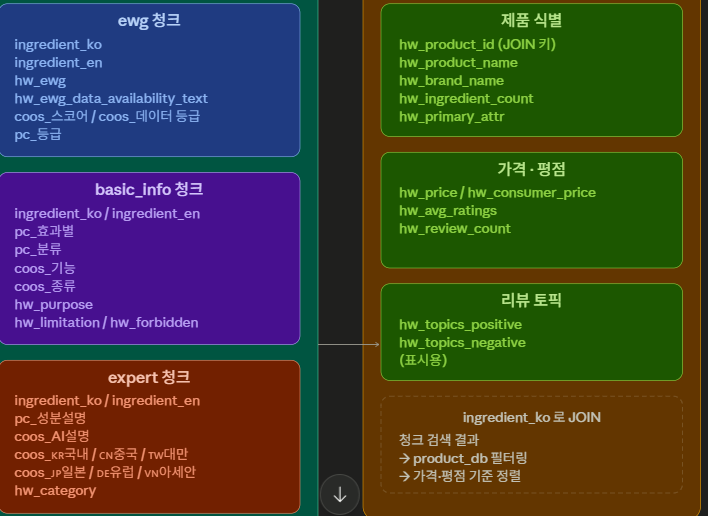

### 청크 변환 파이프라인 — ingredient_merged2.json 기준
- coos_score: 이미 1/2/3으로 정제됨 (기존 [안전]/[주의]/[위험] 텍스트 아님)
- 없어진 컬럼: coos_cas_no, coos_country, hw_ingredient_id, hw_is_allergy, hw_purposes
- product_db.csv: 별도 파일로 이미 존재 (이 스크립트에서 재생성하지 않음)
- 중복 제거: 직접 확인 후 처리할 수 있도록 중복 현황 리포트 출력

In [1]:
import json
import numpy as np
from collections import Counter, defaultdict

In [2]:
# 1. 설정

WEIGHT_PRESETS = {
    1: {"ewg": 0.33, "basic_info": 0.33, "expert": 0.33},   # 균등
    2: {"ewg": 0.50, "basic_info": 0.35, "expert": 0.15},   # EWG 중심
    3: {"ewg": 0.40, "basic_info": 0.45, "expert": 0.15},   # 기본정보 중심
    4: {"ewg": 0.45, "basic_info": 0.45, "expert": 0.10},   # 균형
}

In [3]:
BASE_PATH = "/content/project"
INPUT_FILE = f"{BASE_PATH}/ingredient_merged2.json"

with open(INPUT_FILE, "rb") as f:
    raw = f.read()
if raw[:3] == b'\xef\xbb\xbf':
    raw = raw[3:]
text = raw.decode("utf-8", errors="ignore")
data = json.loads(text)

print(f"총 행 수: {len(data)}")
print(f"컬럼 목록: {list(data[0].keys())}")

총 행 수: 87712
컬럼 목록: ['ingredient_ko', 'ingredient_en', 'pc_rating', 'pc_effect', 'pc_category', 'pc_description', 'coos_function', 'coos_type', 'coos_kr_restricted', 'coos_cn_restricted', 'coos_tw_restricted', 'coos_jp_restricted', 'coos_eu_restricted', 'coos_asean_restricted', 'coos_ai_description', 'coos_score', 'coos_data_grade', 'hw_product_id', 'hw_product_name', 'hw_brand_name', 'hw_avg_ratings', 'hw_review_count', 'hw_price', 'hw_consumer_price', 'hw_primary_attr', 'hw_topics_positive', 'hw_topics_negative', 'hw_ingredient_count', 'hw_ewg', 'hw_ewg_data_availability_text', 'hw_purpose', 'hw_limitation', 'hw_forbidden', 'hw_category']


In [4]:
# 중복 현황 리포트
ing_counts = Counter(row.get("ingredient_ko", "") for row in data)
dup_ingredients = {k: v for k, v in ing_counts.items() if v > 1}

print(f"\n── 중복 현황 ──")
print(f"고유 성분 수: {len(ing_counts)}")
print(f"중복 있는 성분 수: {len(dup_ingredients)}")
print(f"가장 많이 중복되는 성분 TOP 10:")
for name, cnt in sorted(dup_ingredients.items(), key=lambda x: -x[1])[:10]:
    print(f"  {name}: {cnt}회")


── 중복 현황 ──
고유 성분 수: 17144
중복 있는 성분 수: 2393
가장 많이 중복되는 성분 TOP 10:
  정제수: 1642회
  1,2-헥산다이올: 1544회
  부틸렌글라이콜: 1350회
  글리세린: 1273회
  에틸헥실글리세린: 1202회
  티타늄디옥사이드: 878회
  프로판다이올: 787회
  소듐하이알루로네이트: 763회
  토코페롤: 753회
  적색산화철: 743회


In [5]:
# 유효값 필터 함수
def is_valid_value(val) -> bool:
    if val is None:
        return False
    s = str(val).strip()
    if s in ("", "nan", "NaN", "None", "없음", "0"):
        return False
    try:
        if np.isnan(float(s)):
            return False
    except (ValueError, TypeError):
        pass
    return True

In [6]:
def generate_chunks_with_weight(best_rows, current_weights):
    all_chunks = []

    for ing, row in best_rows.items():
        ingredient = str(row.get("ingredient_ko") or "")
        ingredient_en = str(row.get("ingredient_en") or "")
        base_meta = {
            "ingredient_ko": ingredient, "ingredient_en": ingredient_en,
            "coos_score": row.get("coos_score"), "hw_ewg": row.get("hw_ewg"),
            "pc_rating": row.get("pc_rating")
        }

        # 1. EWG 청크
        ewg_parts = []
        if is_valid_value(row.get("coos_score")):
            score_map = {"1": "안전", "2": "주의", "3": "위험"}
            score_label = score_map.get(str(row["coos_score"]), str(row["coos_score"]))
            ewg_parts.append(f"EWG 스코어: {score_label} ({row['coos_score']}등급)")
        if is_valid_value(row.get("hw_ewg")): ewg_parts.append(f"화해 EWG: {row['hw_ewg']}")
        if ewg_parts:
            all_chunks.append({
                "page_content": f"[{ingredient}] " + " / ".join(ewg_parts),
                "metadata": {**base_meta, "chunk_type": "ewg", "chunk_weight": current_weights["ewg"]}
            })

        # 2. Basic Info 청크
        basic_parts = []
        for col, label in [("coos_function", "기능"), ("pc_effect", "효과"), ("hw_purpose", "목적")]:
            if is_valid_value(row.get(col)): basic_parts.append(f"{label}: {row[col]}")
        if basic_parts:
            all_chunks.append({
                "page_content": f"[{ingredient}] " + " / ".join(basic_parts),
                "metadata": {**base_meta, "chunk_type": "basic_info", "chunk_weight": current_weights["basic_info"]}
            })

        # 3. Expert 청크
        expert_parts = []
        if is_valid_value(row.get("pc_description")): expert_parts.append(f"설명: {row['pc_description']}")
        if is_valid_value(row.get("coos_kr_restricted")): expert_parts.append(f"규제: {row['coos_kr_restricted']}")
        if expert_parts:
            all_chunks.append({
                "page_content": f"[{ingredient}] " + " | ".join(expert_parts),
                "metadata": {**base_meta, "chunk_type": "expert", "chunk_weight": current_weights["expert"]}
            })

    return all_chunks

In [7]:
# 최적 행 선별 (한 번만 수행)
ingredient_groups = defaultdict(list)
for row in data:
    ingredient_groups[row.get("ingredient_ko", "")].append(row)

ingredient_cols = ["pc_description", "coos_function", "hw_ewg", "coos_score"]
best_rows = {ing: max(rows, key=lambda r: sum(1 for c in ingredient_cols if is_valid_value(r.get(c))))
             for ing, rows in ingredient_groups.items()}

print(f"--- 일괄 생성 시작 (총 {len(best_rows)}개 성분) ---")

for preset_id, weights in WEIGHT_PRESETS.items():
    # 해당 가중치로 청크 생성
    chunks = generate_chunks_with_weight(best_rows, weights)

    # 파일명 결정
    output_filename = f"{BASE_PATH}/ingredient_chunks_preset{preset_id}.json"

    # 저장
    with open(output_filename, "w", encoding="utf-8") as f:
        json.dump(chunks, f, ensure_ascii=False, indent=2)

    print(f"✅ 프리셋 {preset_id} 완료: {output_filename} (청크 {len(chunks)}개)")
    print(f"   가중치: {weights}")

print("\n✨ 모든 파일 생성 프로세스가 완료되었습니다.")

--- 일괄 생성 시작 (총 17144개 성분) ---
✅ 프리셋 1 완료: /content/project/ingredient_chunks_preset1.json (청크 25855개)
   가중치: {'ewg': 0.33, 'basic_info': 0.33, 'expert': 0.33}
✅ 프리셋 2 완료: /content/project/ingredient_chunks_preset2.json (청크 25855개)
   가중치: {'ewg': 0.5, 'basic_info': 0.35, 'expert': 0.15}
✅ 프리셋 3 완료: /content/project/ingredient_chunks_preset3.json (청크 25855개)
   가중치: {'ewg': 0.4, 'basic_info': 0.45, 'expert': 0.15}
✅ 프리셋 4 완료: /content/project/ingredient_chunks_preset4.json (청크 25855개)
   가중치: {'ewg': 0.45, 'basic_info': 0.45, 'expert': 0.1}

✨ 모든 파일 생성 프로세스가 완료되었습니다.


In [9]:
# 9. 검증 (생성된 4개 파일 전수 조사)
import random
import os

print("══ 파이프라인 생성 결과 검증 ══")

# 앞서 정의한 저장 경로와 일치해야 합니다.
for p_idx in range(1, 5):
    # 파일명 규칙 확인: preset1, preset2...
    file_path = f"{BASE_PATH}/ingredient_chunks_preset{p_idx}.json"

    if not os.path.exists(file_path):
        print(f"\n❌ 파일 없음: {file_path}")
        continue

    with open(file_path, "r", encoding="utf-8") as f:
        check_chunks = json.load(f)

    print(f"\n--- [프리셋 {p_idx}번 파일 검증] ---")
    print(f"1) 경로: {file_path}")
    print(f"2) 총 청크 수: {len(check_chunks)}")

    # 타입별 개수 및 가중치 확인
    type_stats = defaultdict(list)
    for c in check_chunks:
        m = c.get("metadata", {})
        type_stats[m.get("chunk_type")].append(m.get("chunk_weight", 0))

    print(f"3) 타입별 분포 및 가중치:")
    for t in ["ewg", "basic_info", "expert"]:
        weights = type_stats.get(t, [])
        if weights:
            avg_w = sum(weights) / len(weights)
            print(f"   - {t:12}: {len(weights):5}개 (Weight: {avg_w:.2f})")
        else:
            print(f"   - {t:12}: 데이터 없음")

    # 4) 중복 검사 (성분명 + 청크타입 조합이 유니크해야 함)
    print(f"4) 중복성 검사:")
    for chunk_type in ["ewg", "basic_info", "expert"]:
        ings = [c["metadata"]["ingredient_ko"] for c in check_chunks if c["metadata"]["chunk_type"] == chunk_type]
        dup = {k: v for k, v in Counter(ings).items() if v > 1}
        if dup:
            print(f"   ❌ {chunk_type:10} 중복 발견! ({len(dup)}건)")
            # 필요 시 출력: print(f"      예: {list(dup.keys())[:3]}")
        else:
            print(f"   ✅ {chunk_type:10} 중복 없음")

    # 5) 빈 내용 및 샘플 검사
    empty = [c for c in check_chunks if not str(c.get("page_content", "")).strip()]
    if empty:
        print(f"5) ❌ 빈 청크 발견: {len(empty)}개")
    else:
        sample = random.choice(check_chunks)
        print(f"5) ✅ 내용 이상 없음")
        print(f"   [샘플] {sample['metadata']['chunk_type']}: {sample['page_content'][:60]}...")

print("\n✨ 모든 파일 검증 프로세스가 완료되었습니다.")

══ 파이프라인 생성 결과 검증 ══

--- [프리셋 1번 파일 검증] ---
1) 경로: /content/project/ingredient_chunks_preset1.json
2) 총 청크 수: 25855
3) 타입별 분포 및 가중치:
   - ewg         :  7469개 (Weight: 0.33)
   - basic_info  : 17144개 (Weight: 0.33)
   - expert      :  1242개 (Weight: 0.33)
4) 중복성 검사:
   ✅ ewg        중복 없음
   ✅ basic_info 중복 없음
   ✅ expert     중복 없음
5) ✅ 내용 이상 없음
   [샘플] ewg: [센티드제라늄추출물] EWG 스코어: 주의 (2등급) / 화해 EWG: 3...

--- [프리셋 2번 파일 검증] ---
1) 경로: /content/project/ingredient_chunks_preset2.json
2) 총 청크 수: 25855
3) 타입별 분포 및 가중치:
   - ewg         :  7469개 (Weight: 0.50)
   - basic_info  : 17144개 (Weight: 0.35)
   - expert      :  1242개 (Weight: 0.15)
4) 중복성 검사:
   ✅ ewg        중복 없음
   ✅ basic_info 중복 없음
   ✅ expert     중복 없음
5) ✅ 내용 이상 없음
   [샘플] basic_info: [확정세포배양액3] 기능: AI Conditioning EU SKIN CONDITIONING 식 피부컨디셔닝...

--- [프리셋 3번 파일 검증] ---
1) 경로: /content/project/ingredient_chunks_preset3.json
2) 총 청크 수: 25855
3) 타입별 분포 및 가중치:
   - ewg         :  7469개 (Weight: 0.40)
   - basic_info  : 17144개 (We